In [1]:
#for saving images in px
%pip install plotly==5.18.0 kaleido==0.2.1

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_original=pd.read_csv(r"C:\Users\pc\OneDrive\Desktop\meteorites\Meteorite_Landings.csv")
df_original.head()


,name,id,nametype,recclass,mass (g),fall,year,reclat,reclong,GeoLocation
0,Aachen,1,Valid,L5,21.0,Fell,1880.0,50.77500,6.08333,"(50.775, 6.08333)"
1,Aarhus,2,Valid,H6,720.0,Fell,1951.0,56.18333,10.23333,"(56.18333, 10.23333)"
2,Abee,6,Valid,EH4,107000.0,Fell,1952.0,54.21667,-113.00000,"(54.21667, -113.0)"
3,Acapulco,10,Valid,Acapulcoite,1914.0,Fell,1976.0,16.88333,-99.90000,"(16.88333, -99.9)"
4,Achiras,370,Valid,L6,780.0,Fell,1902.0,-33.16667,-64.95000,"(-33.16667, -64.95)"


In [3]:
df=df_original.copy()

In [4]:
#GeoLocation is useless, we can drop it
df=df.drop(columns=["GeoLocation"])

In [5]:
df.head()

,name,id,nametype,recclass,mass (g),fall,year,reclat,reclong
0,Aachen,1,Valid,L5,21.0,Fell,1880.0,50.77500,6.08333
1,Aarhus,2,Valid,H6,720.0,Fell,1951.0,56.18333,10.23333
2,Abee,6,Valid,EH4,107000.0,Fell,1952.0,54.21667,-113.00000
3,Acapulco,10,Valid,Acapulcoite,1914.0,Fell,1976.0,16.88333,-99.90000
4,Achiras,370,Valid,L6,780.0,Fell,1902.0,-33.16667,-64.95000


Explaining meaning of features:

-nametype : Is the name official?  
Valid = official approved name by scientists (99% are Valid)  
Relict = old name, no longer used, maybe debris

-recclass: Most important scientific column.  
Type of meteorite rock.  
L5 = Low iron, type 5  
H6 = High iron, type 6  
Martian = from Mars!  
Iron = pure iron  

-fall: How was it found?  
Fell = People SAW it fall from sky with fire, then found it (only 4% are Fell, rare and valuable)  
Found = People just found it on ground later, didn't see it fall (96% are Found, mostly in Antarctica desert)



In [6]:
print(df.dtypes)
print("\nsize of data is: {}".format(df.size))

name         object
id            int64
nametype     object
recclass     object
mass (g)    float64
fall         object
year        float64
reclat      float64
reclong     float64
dtype: object

size of data is: 411444


In [7]:
print("Percentage of missing values:\n\n{}".format((df.isnull().sum()/len(df)*100).round(2)))

Percentage of missing values:

name         0.00
id           0.00
nametype     0.00
recclass     0.00
mass (g)     0.29
fall         0.00
year         0.64
reclat      16.00
reclong     16.00
dtype: float64


 How to deal with missing values?

-mass: 0.29% missing = TINY
 Drop rows where mass = 0 or null + keep the rest

-year: 0.64% missing = TINY
What to do: DROP nulls + convert to number

-reclat: 16% missing = MEDIUM
What to do: DROP nulls for map only - needed for Chart 

-reclong: 16% missing = MEDIUM
What to do: DROP nulls for map only - same as reclat






In [8]:
for col in df.columns:
    print("\n======={}=======\n".format(col))
    print(df[col].value_counts())


=======name=======

Aachen                    1
Northwest Africa 7459     1
Northwest Africa 7404     1
Northwest Africa 7407     1
Northwest Africa 7408     1
                         ..
Grove Mountains 052250    1
Grove Mountains 052253    1
Grove Mountains 052254    1
Grove Mountains 052256    1
Zulu Queen                1
Name: name, Length: 45716, dtype: int64

=======id=======

1        1
56115    1
55773    1
55774    1
55775    1
        ..
48288    1
46972    1
50381    1
46973    1
30414    1
Name: id, Length: 45716, dtype: int64

=======nametype=======

Valid     45641
Relict       75
Name: nametype, dtype: int64

=======recclass=======

L6         8285
H5         7142
L5         4796
H6         4528
H4         4211
           ... 
EL7           1
CH/CBb        1
H/L~4         1
LL3.7-6       1
L/LL          1
Name: recclass, Length: 466, dtype: int64

=======mass (g)=======

1.30       171
1.20       140
1.40       138
2.10       130
2.40       126
          ... 
129.33   

In [9]:
df = df.rename(columns={'mass (g)': 'mass'})

In [10]:
df=df.dropna(subset=["mass","year","reclat","reclong"])

In [11]:
df.isnull().sum() #cleaning verified

name        0
id          0
nametype    0
recclass    0
mass        0
fall        0
year        0
reclat      0
reclong     0
dtype: int64

In [12]:
# now start coding for charts for when


In [13]:
df[["year"]].value_counts().head(10)

year  
1979.0    3045
1988.0    2295
1998.0    2147
2003.0    1754
2006.0    1616
1999.0    1592
1990.0    1506
1997.0    1505
2000.0    1502
2009.0    1496
dtype: int64

In [14]:
df["year"]=df["year"].astype(int)
df["year"].head()

0    1880
1    1951
2    1952
3    1976
4    1902
Name: year, dtype: int32

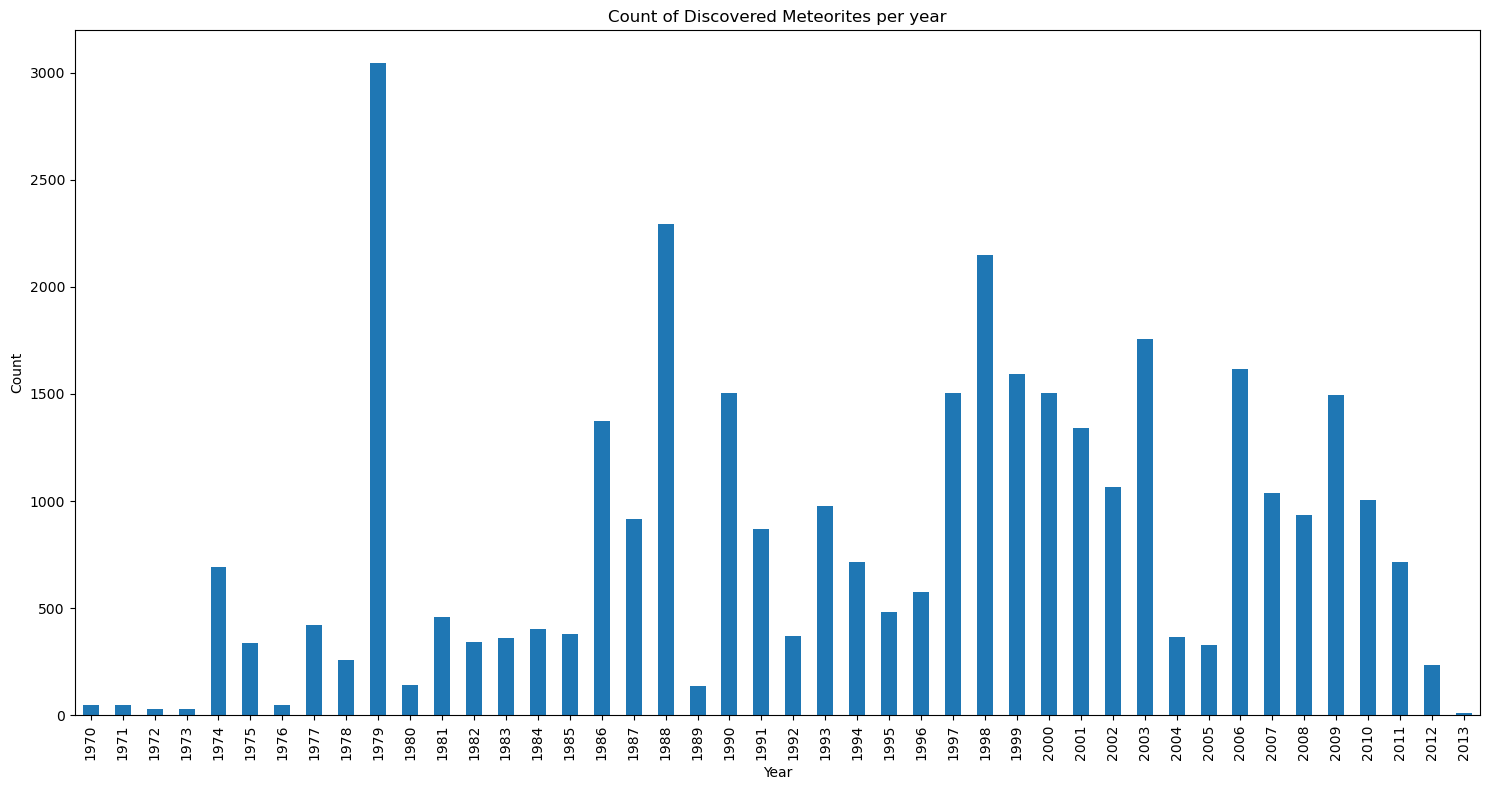

In [15]:
counts = df["year"].value_counts().sort_index()
# filter zoom first, so bar index matches years
counts_zoom = counts.loc[1970:2020]

counts_zoom.plot(kind="bar", figsize=(15,8))

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Count of Discovered Meteorites per year")

plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("BarChart_Time_Discovered.png", bbox_inches='tight')

plt.show()


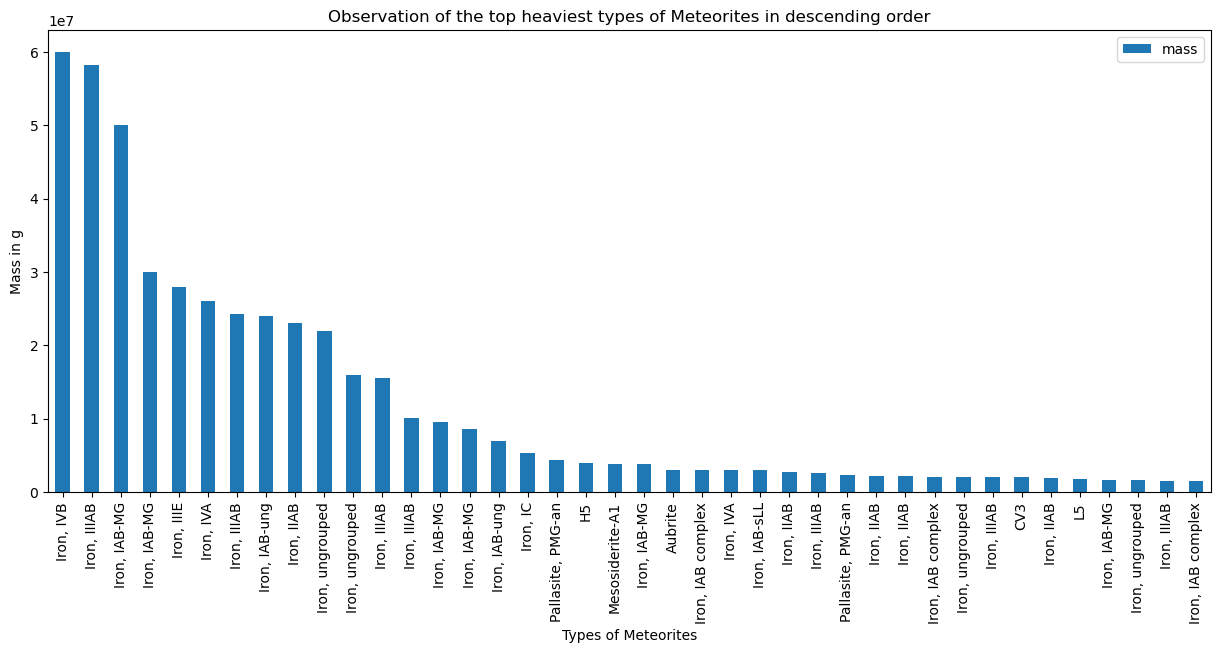

In [16]:
#What are the heaviest types of meteorites? 
df[["mass","recclass"]].sort_values(by="mass",ascending=False).head(40).plot(kind="bar",
                                                                             x="recclass",
                                                                             y="mass",figsize=(15,6))
plt.xlabel("Types of Meteorites")
plt.ylabel("Mass in g")
plt.title("Observation of the top heaviest types of Meteorites in descending order")
plt.savefig("BarChart_Heaviest_Types.png", bbox_inches='tight')
plt.show()


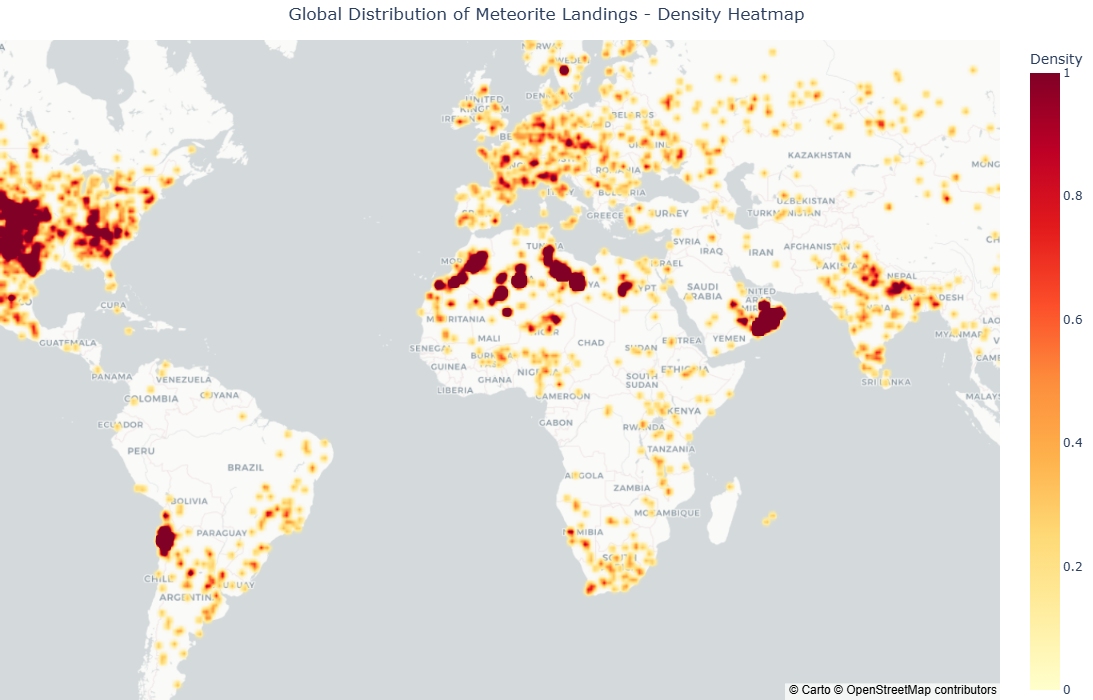

In [30]:
#plot on worldmap by density
import plotly.express as px

df_map = df[(df["reclat"] != 0) & (df["reclong"] != 0)]

fig = px.density_mapbox(df_map, 
                        lat="reclat", 
                        lon="reclong",
                        radius=6,
                        center=dict(lat=10, lon=0), 
                        zoom=1.75,
                        mapbox_style="carto-positron", 
                        title="Global Distribution of Meteorite Landings - Density Heatmap",
                        color_continuous_scale="YlOrRd")

fig.update_layout(height=700,width=1000, title_x=0.5,title_xanchor='center',margin={"r":0,"t":40,"l":0,"b":0})
fig.update_coloraxes(colorbar_title="Density")
fig.write_image("World_map_Meteorites_Density.png", width=1200, height=800, scale=2)

fig.show()


In [31]:
import os
print(os.getcwd())

C:\Users\pc\OneDrive\Desktop\meteorites
